In [1]:
import torch

In [2]:
B = 1
LEN = 4
D = 5

x = torch.randn((B, LEN, D))
x

tensor([[[-1.4963,  0.9888, -1.2176, -1.5970, -0.4035],
         [-1.3507,  0.9153, -0.4470, -0.0570,  1.5490],
         [ 0.2331,  1.0985,  0.8471, -1.0102,  0.6278],
         [-0.6642, -0.2886, -0.1704, -0.3552,  1.1803]]])

In [3]:
Wq = torch.randn((D, D))
Wk = torch.randn((D, D))
Wv = torch.randn((D, D))

In [4]:
q = x @ Wq
k = x @ Wk
v = x @ Wv
print(q.shape)

torch.Size([1, 4, 5])


## self-attention

In [5]:
scores = q @ k.transpose(-2, -1) / torch.sqrt(torch.tensor(D))
print(scores.shape)
scores

torch.Size([1, 4, 4])


tensor([[[ 2.9338, -1.4067,  0.9940, -3.5110],
         [ 4.9339,  3.4264, -3.7750,  0.6862],
         [ 0.6362, -1.2268,  3.5062, -0.5703],
         [ 1.0949,  1.8758, -1.4928,  1.1759]]])

In [6]:
att_matrix = torch.softmax(scores, dim=-1)
print(att_matrix.shape)
print(torch.sum(att_matrix, dim=-1))
att_matrix

torch.Size([1, 4, 4])
tensor([[1.0000, 1.0000, 1.0000, 1.0000]])


tensor([[[8.6330e-01, 1.1249e-02, 1.2408e-01, 1.3716e-03],
         [8.0911e-01, 1.7919e-01, 1.3359e-04, 1.1568e-02],
         [5.2383e-02, 8.1300e-03, 9.2381e-01, 1.5675e-02],
         [2.3025e-01, 5.0275e-01, 1.7313e-02, 2.4968e-01]]])

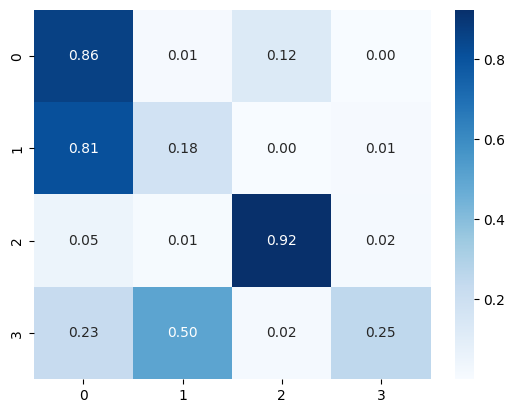

In [7]:
# faz um heatmap da matriz de atenção
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(att_matrix.squeeze(0).detach().numpy(), annot=True, cmap="Blues", fmt=".2f")
plt.show()

In [ ]:
att = att_matrix @ v
print(att.shape)
att

## masked self-attention

In [ ]:
mask =  torch.tril((torch.ones((LEN, LEN)))).unsqueeze(0).repeat(B, 1, 1)
print(mask.shape)
mask

In [ ]:
masked_scores = scores.masked_fill(mask == 0, float('-inf'))
masked_scores

In [ ]:
masked_att_matrix = torch.softmax(masked_scores, dim=-1)
print(torch.sum(masked_att_matrix, dim=-1))
masked_att_matrix

In [ ]:
sns.heatmap(masked_att_matrix.squeeze(0).detach().numpy(), annot=True, cmap="Blues", fmt=".2f")
plt.show()

In [ ]:
masked_att = masked_att_matrix @ v
print(masked_att.shape)
masked_att

## cross-attention

In [ ]:
LEN_Y = 6

y = torch.randn((B, LEN_Y, D))
y

In [ ]:
k_y = y @ Wk
v_y = y @ Wv
print(k_y.shape)
print(v_y.shape)

In [ ]:
cross_scores = q @ k_y.transpose(-2, -1) / torch.sqrt(torch.tensor(D))
print(cross_scores.shape)
cross_scores

In [ ]:
cross_matrix = torch.softmax(cross_scores, dim=-1)
print(cross_matrix.shape)
print(torch.sum(cross_matrix, dim=-1))
cross_matrix

In [ ]:
sns.heatmap(cross_matrix.squeeze(0).detach().numpy(), annot=True, cmap="Blues", fmt=".2f")
plt.show()

In [ ]:
cross_att = cross_matrix @ v_y
print(cross_att.shape)
cross_att

## constroi um modulo

In [ ]:
import torch.nn as nn

class QKVAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, q, k, v, mask=None, return_att_matrix=False):
        scores = q @ k.transpose(-2, -1) / (q.shape[-1]**0.5)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        att_matrix = torch.softmax(scores, dim=-1)
        att = att_matrix @ v
        if return_att_matrix:
            return att, att_matrix
        return att

In [ ]:
with torch.no_grad():
    qkv_att = QKVAttention()
    qkv_att = qkv_att(q, k, v)
    print(qkv_att.shape)
    print(torch.allclose(att, qkv_att))

In [ ]:
with torch.no_grad():
    qkv_att = QKVAttention()
    qkv_att = qkv_att(q, k, v, mask)
    print(qkv_att.shape)
    print(torch.allclose(masked_att, qkv_att))

In [ ]:
with torch.no_grad():
    qkv_att = QKVAttention()
    qkv_att = qkv_att(q, k_y, v_y)
    print(qkv_att.shape)
    print(torch.allclose(cross_att, qkv_att))